1. Download the datasets and set the environment

In [2]:
import os
import urllib.request
import tarfile

url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

filename = "aclImdb_v1.tar.gz"

if not os.path.exists(filename):
    print(f"loading...{filename}")
    urllib.request.urlretrieve(url, filename)
    print("done!")

else:
    print("the file has already exisited, skip loading")

if not os.path.exists("aclImdb"):
    print("unzipping...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print("done!")
else:
    print("meue 'aclImdb' already exisited, skip unzipping")

loading...aclImdb_v1.tar.gz
done!
unzipping...


/tmp/ipykernel_2216/627302898.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


done!


In [3]:
!nvidia-smi

Fri Mar 27 07:53:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
import os

base_dir = 'aclImdb'
train_pos_dir = os.path.join(base_dir, 'train', 'pos')
train_neg_dir = os.path.join(base_dir, 'train', 'neg')

print(f"postive training number : {len(os.listdir(train_pos_dir))}")
print(f"negative training number: {len(os.listdir(train_neg_dir))}")

postive training number : 12500
negative training number: 12500


In [5]:
from transformers import AutoTokenizer
import os
import torch
from torch.utils.data import Dataset, DataLoader

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class IMDbDataset(Dataset):
    def __init__(self, root_dir, tokenizer, max_length=256, sample_size = 5000):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.texts = []
        self.labels = []

        #load pos and neg files
        for label_type in ['pos', 'neg']:
            dir_name = os.path.abspath(os.path.join(root_dir, label_type))
            label = 1 if label_type == 'pos' else 0

            print(f"viewing menu {dir_name}")

            if not os.path.exists(dir_name):
                print(f"can't find the menu : {dir_name}")
                continue

            files = os.listdir(dir_name)
            valid_files = [f for f in files if f.endswith('.txt')]

            selected_files = valid_files[:sample_size]
            print(f"in {label_type} find {len(valid_files)} data, choose {len(selected_files)} data")

            for f in selected_files:
                    file_path = os.path.join(dir_name, f)
                    with open(os.path.join(dir_name, f), 'r' , encoding='utf-8') as file:
                        self.texts.append(file.read())
                        self.labels.append(label)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding = 'max_length',
            truncation = True,
            max_length = self.max_length,
            return_tensors = 'pt'
        )

        return {
            'input_ids' : encoding['input_ids'].flatten(),
            'attention_mask' : encoding['attention_mask'].flatten(),
            'label' : torch.tensor(label, dtype=torch.long)
        }

train_dataset = IMDbDataset('aclImdb/train', tokenizer)
train_loader = DataLoader(train_dataset, batch_size = 8, shuffle= True)

print(f"Dataset setting is done! totally have {len(train_dataset)} data")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

viewing menu /content/aclImdb/train/pos
in pos find 12500 data, choose 5000 data
viewing menu /content/aclImdb/train/neg
in neg find 12500 data, choose 5000 data
Dataset setting is done! totally have 10000 data


2. establish the model - BERT

In [6]:
import torch.nn as nn
from transformers import AutoModel

class SentimentClassifier(nn.Module):
    def __init__(self, model_name):
        super(SentimentClassifier, self).__init__()
        #1.load transformer
        self.transformer = AutoModel.from_pretrained(model_name)

        #2. forzen transformer parameters
        for param in self.transformer.parameters():
            param.requires_grad = False

        #3. designe the classifier
        #DistilBert 's hidden layer is 768
        self.classifier = nn.Sequential(
            nn.Linear(768,128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128,2) #2 means two class, pos and neg
        )
    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids= input_ids, attention_mask= attention_mask)

        #get the last layer's hidden status ([CLS])
        ## [batch_size, sequence_length, hidden_size] -> [batch_size, hidden_size]
        last_hidden_state = outputs.last_hidden_state
        cls_output = last_hidden_state[:,0,:]

        #put into the classifier
        logits = self.classifier(cls_output)
        return logits

#initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SentimentClassifier("distilbert-base-uncased").to(device)

print(f"model is ready, now is runnig: {device}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model is ready, now is runnig: cuda


3. Training & Plotting

In [7]:
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. define opitmizer and loss function
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

history = {'loss': [], 'acc': []}

In [8]:
#2. start training(first set one epoch to test speed)
epochs = 1
print("--start training--")
model.train()
for epoch in range(epochs):
    total_loss = 0
    correct = 0

    #1250 bath (10000/ batch_size 8)
    for i, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        #forward
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        #backword
        loss.backward()
        optimizer.step()

        #cumulative data
        total_loss += loss.item()
        _, preds = torch.max(outputs, dim=1)
        correct += torch.sum(preds==labels)

        #every 50 batch print the proccess
        if (i+1) % 50 == 0:
            print(f"Batch {i+1}/{len(train_loader)} is processing")

    #calculate the average value
    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct.double() / len(train_dataset)
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc.item())

    print(f"Epoch {epoch + 1} is done! Loss : {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")



--start training--
Batch 50/1250 is processing
Batch 100/1250 is processing
Batch 150/1250 is processing
Batch 200/1250 is processing
Batch 250/1250 is processing
Batch 300/1250 is processing
Batch 350/1250 is processing
Batch 400/1250 is processing
Batch 450/1250 is processing
Batch 500/1250 is processing
Batch 550/1250 is processing
Batch 600/1250 is processing
Batch 650/1250 is processing
Batch 700/1250 is processing
Batch 750/1250 is processing
Batch 800/1250 is processing
Batch 850/1250 is processing
Batch 900/1250 is processing
Batch 950/1250 is processing
Batch 1000/1250 is processing
Batch 1050/1250 is processing
Batch 1100/1250 is processing
Batch 1150/1250 is processing
Batch 1200/1250 is processing
Batch 1250/1250 is processing
Epoch 1 is done! Loss : 0.6422, Accuracy: 0.7022


In [9]:
extra_epochs = 4
start_epoch = len(history['loss'])

print(f"---from Epoch {start_epoch +1} start keeping training---")

model.train()
for epoch in range(start_epoch, start_epoch +extra_epochs):
    total_loss = 0
    correct = 0

    for i, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        #forward
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        #backword
        loss.backward()
        optimizer.step()

        #cumulative data
        total_loss += loss.item()
        _, preds = torch.max(outputs, dim=1)
        correct += torch.sum(preds==labels)

        #every 100 batch print the proccess
        if (i+1) % 100 == 0:
            print(f"Batch {i+1}/{len(train_loader)} is processing")

    #calculate the average value
    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct.double() / len(train_dataset)
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc.item())

    print(f"Epoch {epoch + 1} is done! Loss : {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")



---from Epoch 2 start keeping training---
Batch 100/1250 is processing
Batch 200/1250 is processing
Batch 300/1250 is processing
Batch 400/1250 is processing
Batch 500/1250 is processing
Batch 600/1250 is processing
Batch 700/1250 is processing
Batch 800/1250 is processing
Batch 900/1250 is processing
Batch 1000/1250 is processing
Batch 1100/1250 is processing
Batch 1200/1250 is processing
Epoch 2 is done! Loss : 0.5385, Accuracy: 0.7896
Batch 100/1250 is processing
Batch 200/1250 is processing
Batch 300/1250 is processing
Batch 400/1250 is processing
Batch 500/1250 is processing
Batch 600/1250 is processing
Batch 700/1250 is processing
Batch 800/1250 is processing
Batch 900/1250 is processing
Batch 1000/1250 is processing
Batch 1100/1250 is processing
Batch 1200/1250 is processing
Epoch 3 is done! Loss : 0.4718, Accuracy: 0.8019
Batch 100/1250 is processing
Batch 200/1250 is processing
Batch 300/1250 is processing
Batch 400/1250 is processing
Batch 500/1250 is processing
Batch 600/125

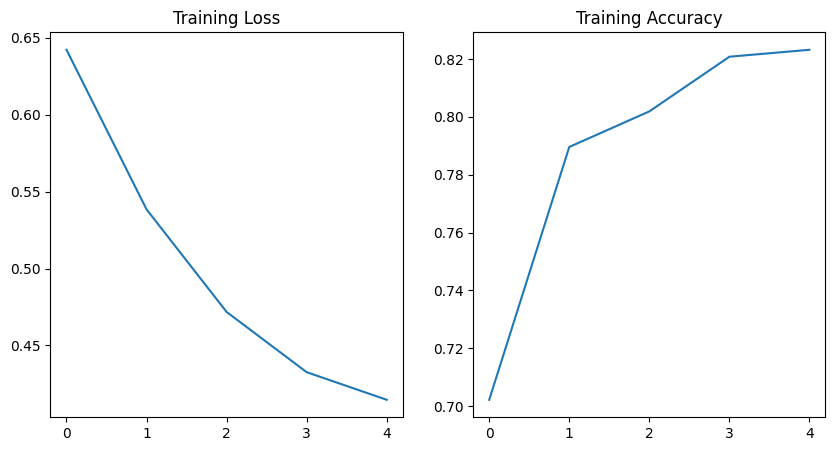

In [10]:
import matplotlib.pyplot as plt
#plot
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history['loss'],label = 'Loss')
plt.title('Training Loss')


plt.subplot(1,2,2)
plt.plot(history['acc'], label = 'Accuracy')
plt.title('Training Accuracy')


plt.show()

4. Evaluation

In [14]:
#create test dataset
test_dataset = IMDbDataset('aclImdb/test', tokenizer, sample_size = 1000 )
test_loader = DataLoader(test_dataset, batch_size = 8, shuffle= False)

#evaluation model
model.eval()
test_correct = 0
with torch.no_grad():
  for batch in test_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['label'].to(device)

    outputs = model(input_ids, attention_mask)
    _, preds = torch.max(outputs, dim=1)
    test_correct += torch.sum(preds == labels)

#calcuate accuracy
test_acc = test_correct / len(test_dataset)

#perform the results
print(f"Test Accuracy : {test_acc:.4f}")

viewing menu /content/aclImdb/test/pos
in pos find 12500 data, choose 1000 data
viewing menu /content/aclImdb/test/neg
in neg find 12500 data, choose 1000 data
Test Accuracy : 0.8070


In [25]:
#random baseline
import random
random_correct = 0

for i in range(len(test_dataset)):
  pred = random.randint(0,1) #random guess:0,1
  label = test_dataset.labels[i]

  if pred == label:
    random_correct += 1

random_acc = random_correct / len(test_dataset)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Random Baseline Accuracy: {random_acc:.4f}")
improvement = (test_acc - random_acc) *100
print(f"The model outperforms the random baseline by {improvement:.2f}%.")


Test Accuracy : 0.8070
Random Baseline Accuracy: 0.4840
The model outperforms the random baseline by 32.30%.


# Reflection
The model achieves an accuracy of 0.80, which is significantly higher than random baseline(0.48).This indicates that the model is able to learn meaningful patterns for sentiment classification.

During this assignment, I found working with the transformer model(DistilBERT) and mangaging GPU memory to be the most challenging part. It was educational to see how pre-trained languages models can be integrated into a custom classifier and how tokenization affects the input. The part that took the most time was preparing the dataset and debugging th DataLoader to ensure the batches were correctly formatted. Some aspects, such as handling large datasets with limted resources and freezing transdormer parameters, felt unnecessarily tricky given the scope of a basic G-level assignment.

One limitation is that only a subset of the dataset was used and the transformer was not fine-tuned. Future work could explore fine-tuning the model or using more data to further improve performance.